<a href="https://colab.research.google.com/github/Dathu-03184/DL_Lab-Programs/blob/main/16%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Best Hyperparameters ===
{'activation': 'tanh', 'hidden_layer_sizes': (20, 10), 'learning_rate_init': 0.1}
Best Cross-Validation Accuracy: 0.983

=== Test Set Accuracy ===
Accuracy: 1.000


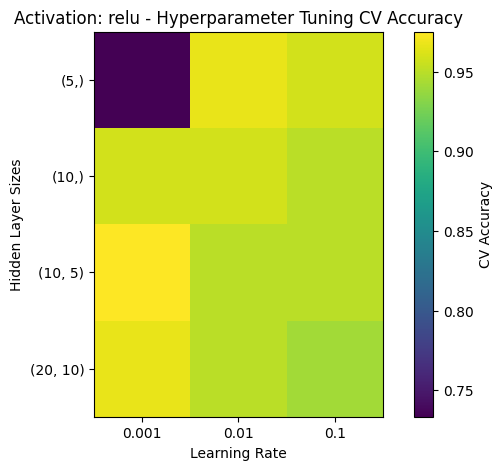

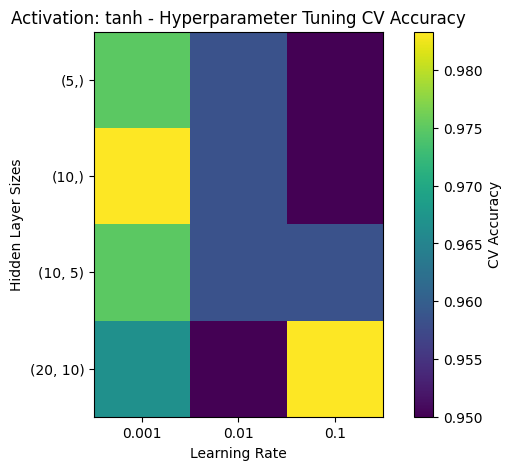

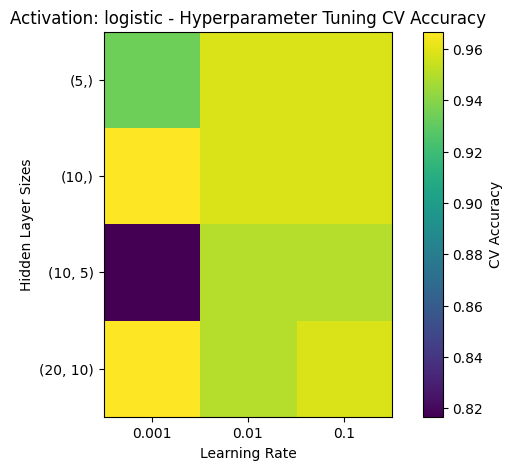

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1️⃣ Load dataset
data = load_iris()
X = data.data
y = data.target

# 2️⃣ Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3️⃣ Define neural network and hyperparameter grid
mlp = MLPClassifier(max_iter=500, random_state=42)

param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (10,5), (20,10)],
    'activation': ['relu', 'tanh', 'logistic'],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

# 4️⃣ Grid Search with Cross-Validation
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy', n_jobs=-1, return_train_score=True)
grid_search.fit(X_train, y_train)

# 5️⃣ Best hyperparameters
print("=== Best Hyperparameters ===")
print(grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.3f}")

# 6️⃣ Evaluate on Test Set
best_mlp = grid_search.best_estimator_
y_pred = best_mlp.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print("\n=== Test Set Accuracy ===")
print(f"Accuracy: {test_accuracy:.3f}")

# 7️⃣ Visualization: Heatmap of mean CV scores for hidden_layer_sizes vs learning_rate_init for each activation
results = pd.DataFrame(grid_search.cv_results_)

for act in param_grid['activation']:
    subset = results[results['param_activation'] == act]
    pivot_table = subset.pivot(index='param_hidden_layer_sizes', columns='param_learning_rate_init', values='mean_test_score')

    plt.figure(figsize=(8,5))
    plt.imshow(pivot_table, cmap='viridis', interpolation='nearest')
    plt.colorbar(label='CV Accuracy')
    plt.xticks(range(len(pivot_table.columns)), pivot_table.columns)
    plt.yticks(range(len(pivot_table.index)), [str(i) for i in pivot_table.index])
    plt.xlabel('Learning Rate')
    plt.ylabel('Hidden Layer Sizes')
    plt.title(f'Activation: {act} - Hyperparameter Tuning CV Accuracy')
    plt.show()
